# Capstone 3: Marketing Campaign 

## Exploratory Data Analysis 

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load dataset 
df = pd.read_csv("/Users/rupashree/Downloads/cleaned_marketing_data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,3,11,1,69,0,1617,4968
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,3,11,0,72,2,27,4418
2,4141,1965,Graduation,Couple,71613.0,0,0,21-08-2013,26,426,...,0,0,0,3,11,0,61,0,776,4617
3,6182,1984,Graduation,Couple,26646.0,1,0,10-02-2014,26,11,...,0,0,0,3,11,0,42,1,53,4444
4,5324,1981,PhD,Couple,58293.0,1,0,19-01-2014,94,173,...,0,0,0,3,11,0,45,1,422,4466


In [6]:
# Basic data overview 
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239 entries, 0 to 2238
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2239 non-null   int64  
 1   Year_Birth           2239 non-null   int64  
 2   Education            2239 non-null   object 
 3   Marital_Status       2239 non-null   object 
 4   Income               2239 non-null   float64
 5   Kidhome              2239 non-null   int64  
 6   Teenhome             2239 non-null   int64  
 7   Dt_Customer          2239 non-null   object 
 8   Recency              2239 non-null   int64  
 9   MntWines             2239 non-null   int64  
 10  MntFruits            2239 non-null   int64  
 11  MntMeatProducts      2239 non-null   int64  
 12  MntFishProducts      2239 non-null   int64  
 13  MntSweetProducts     2239 non-null   int64  
 14  MntGoldProds         2239 non-null   int64  
 15  NumDealsPurchases    2239 non-null   i

In [22]:
# Check missing values
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
Total_Children         0
Total_Spending         0
Customer_Tenure        0
Total_Purchases        0
dtype: int64

In [21]:
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

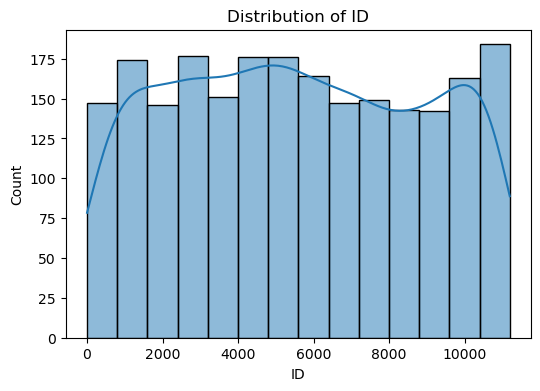

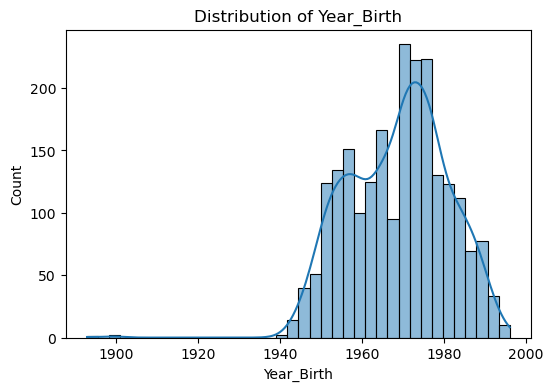

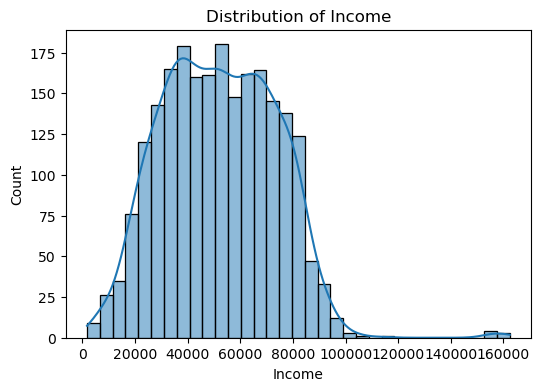

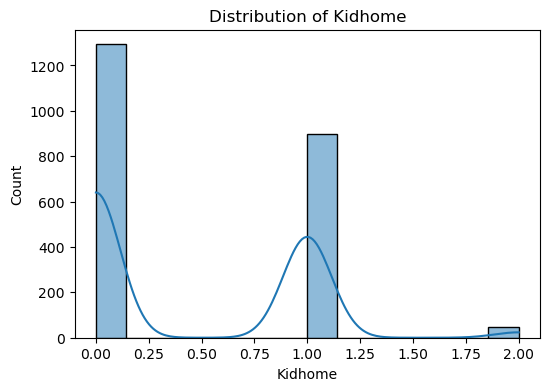

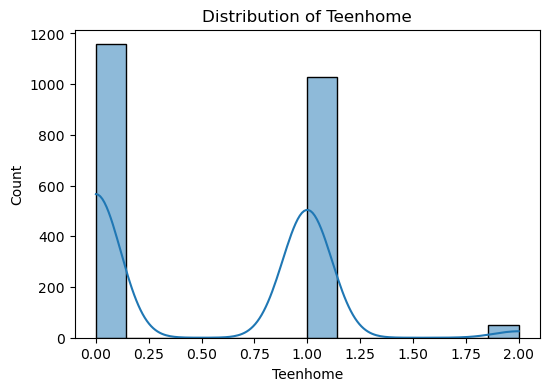

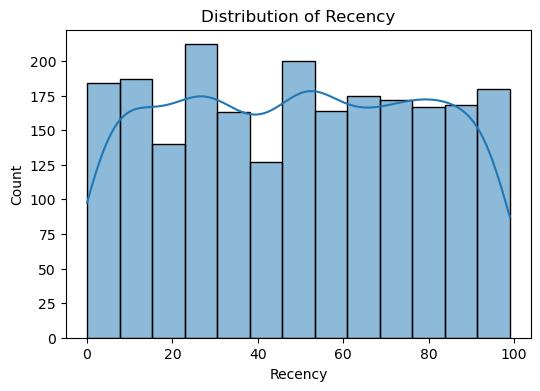

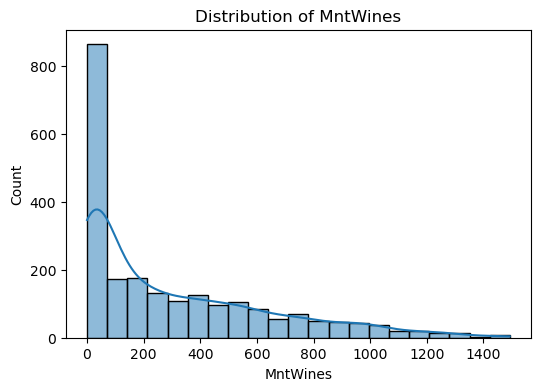

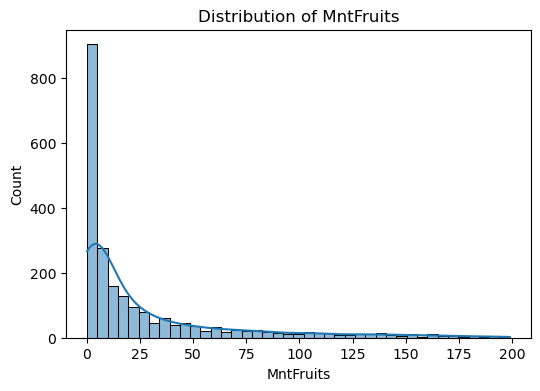

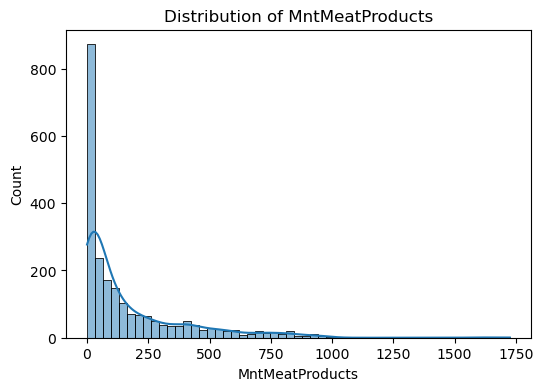

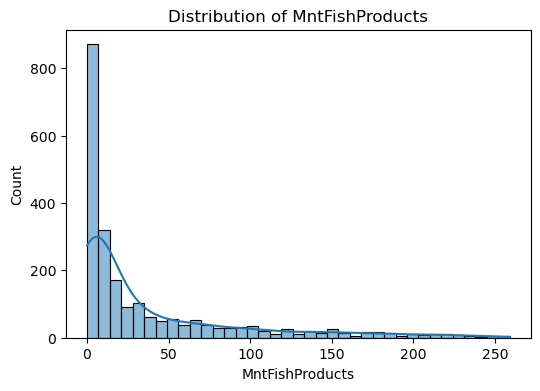

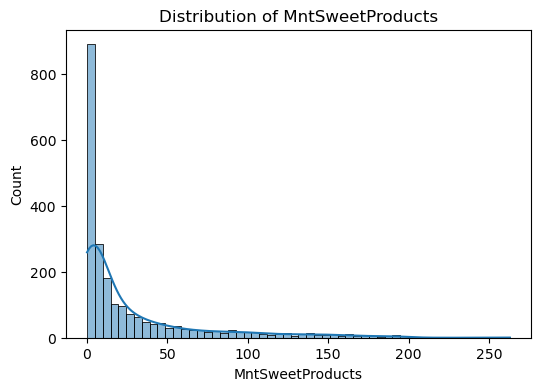

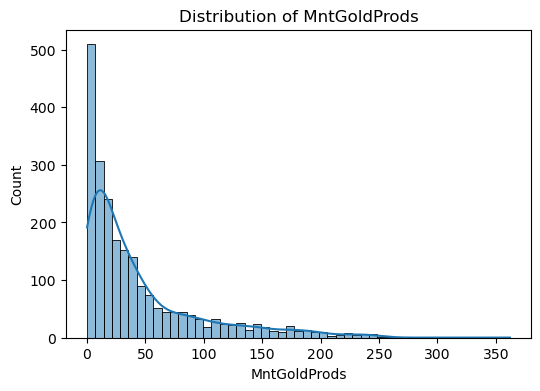

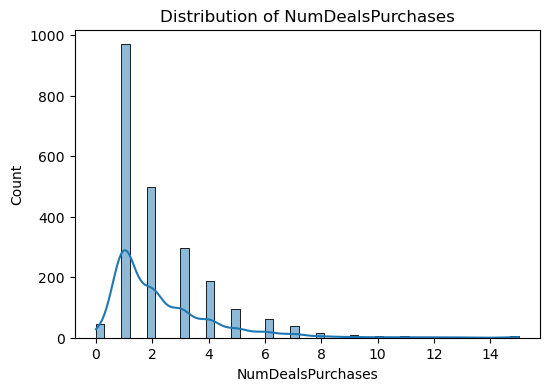

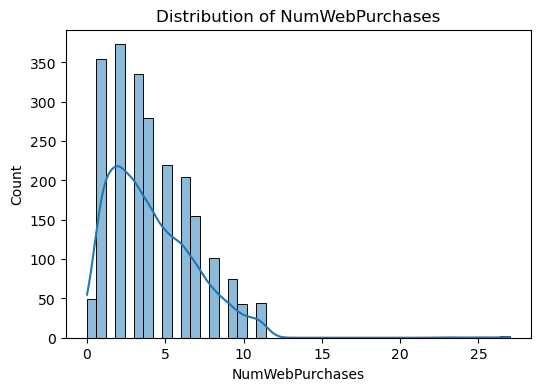

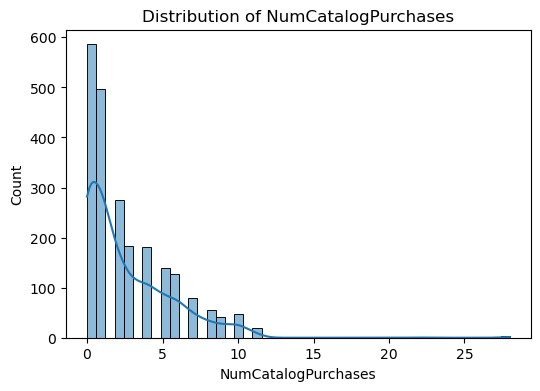

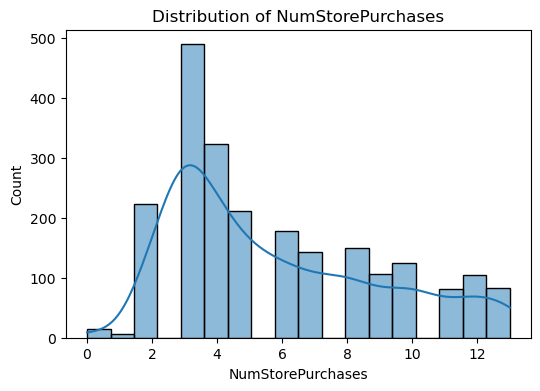

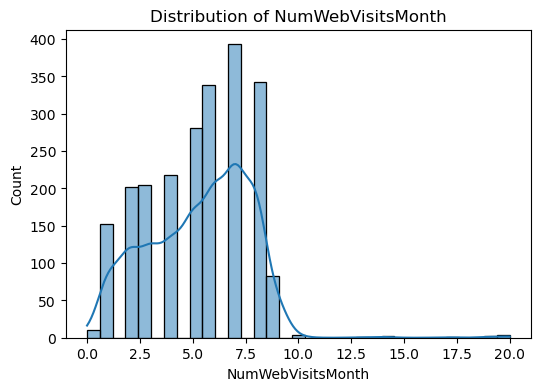

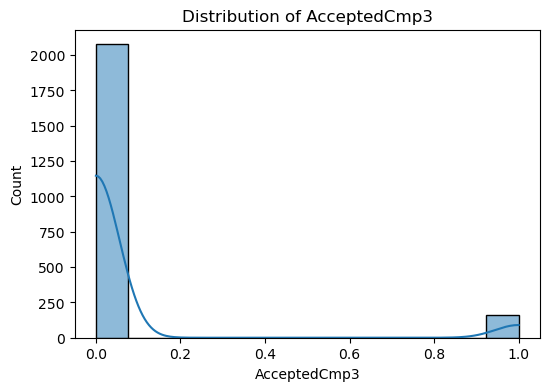

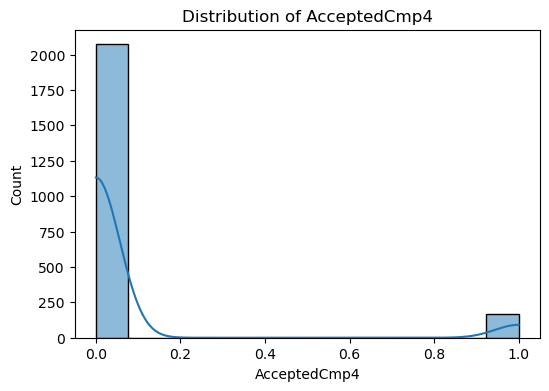

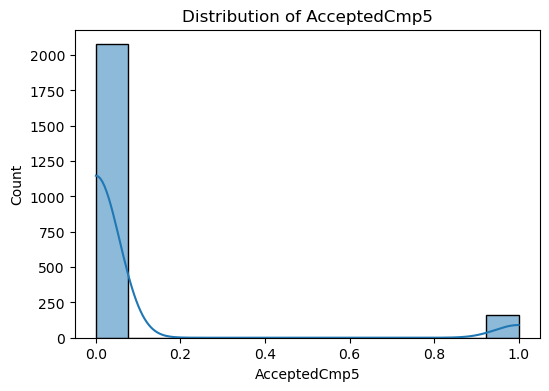

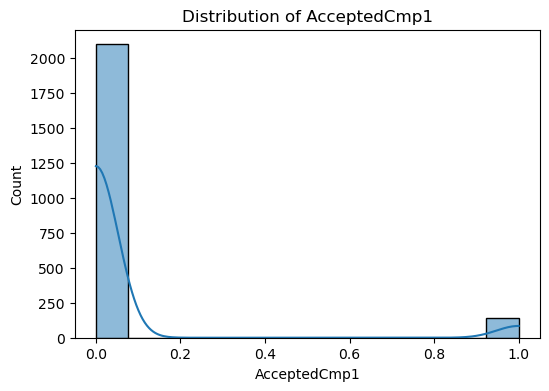

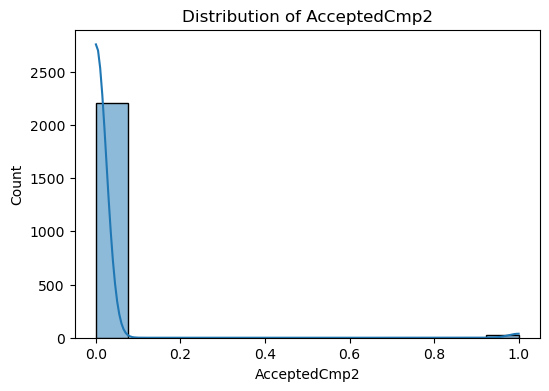

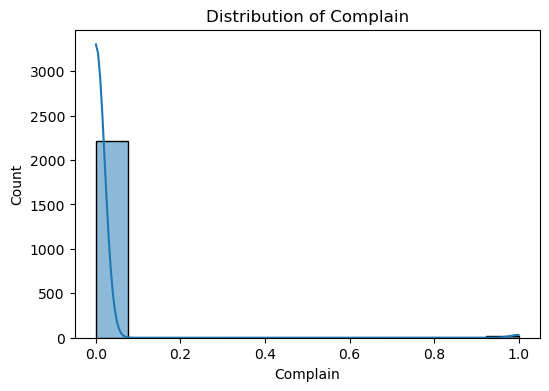

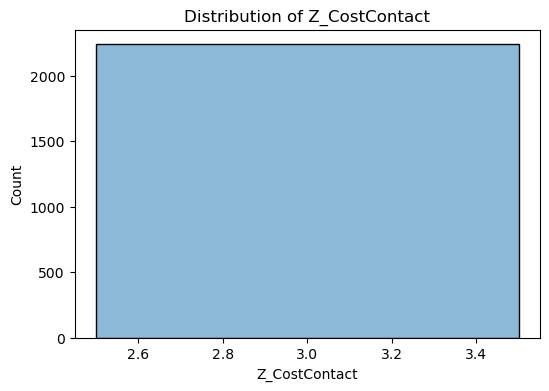

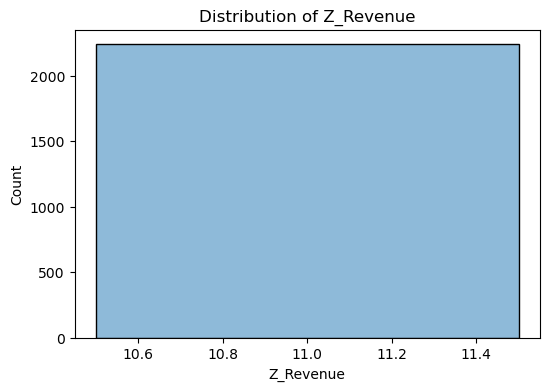

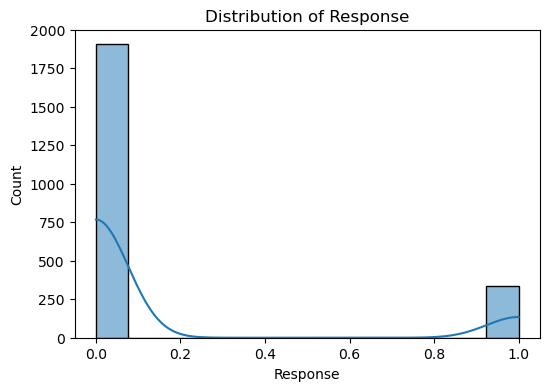

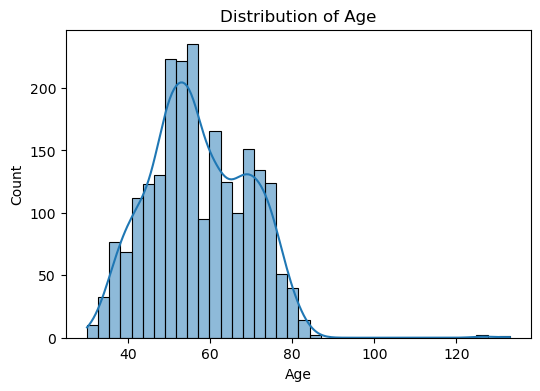

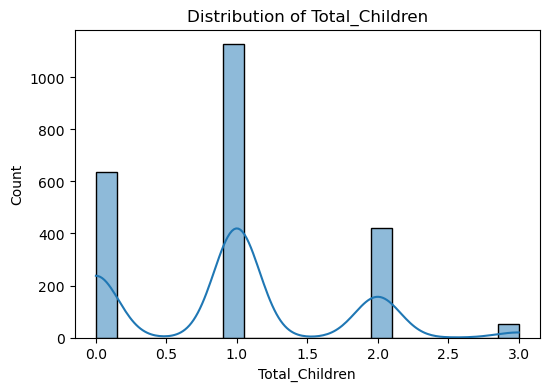

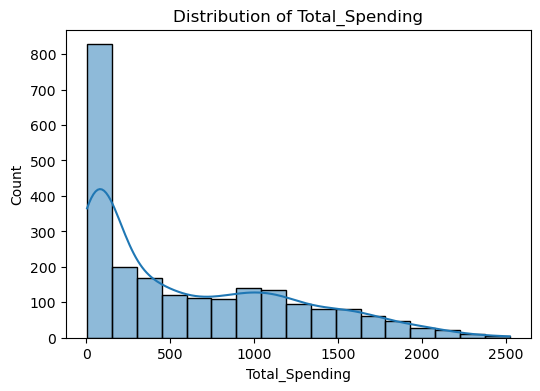

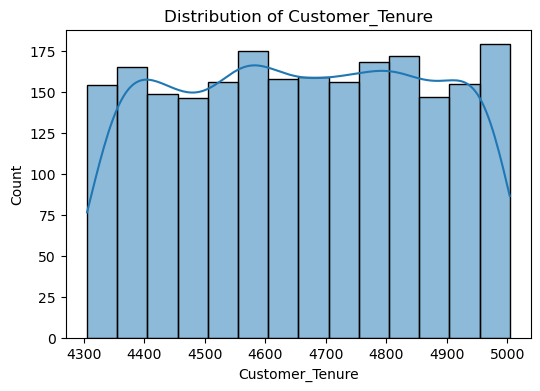

In [8]:
# Numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

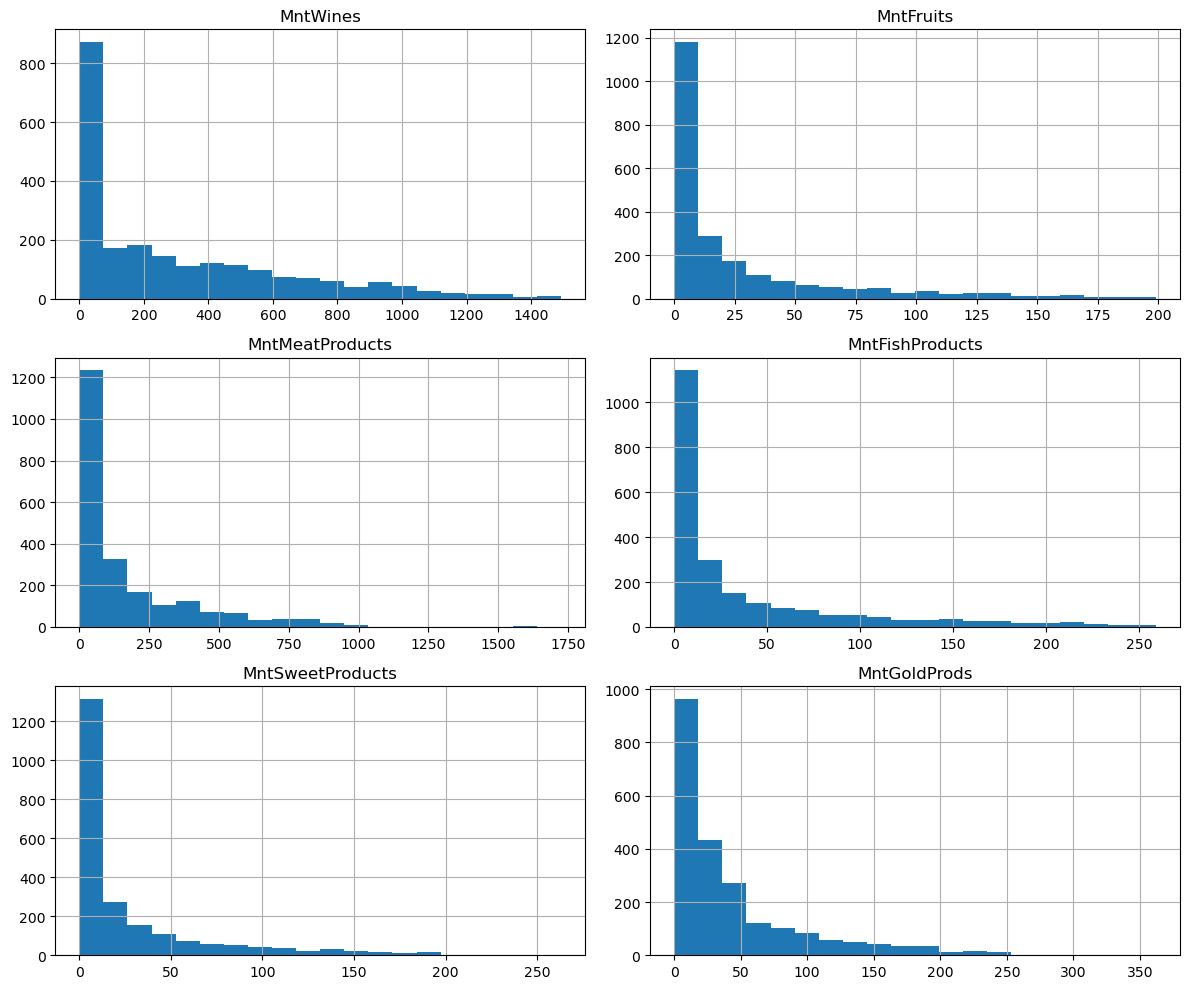

In [11]:
# Categorical Features
spending_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

df[spending_cols].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

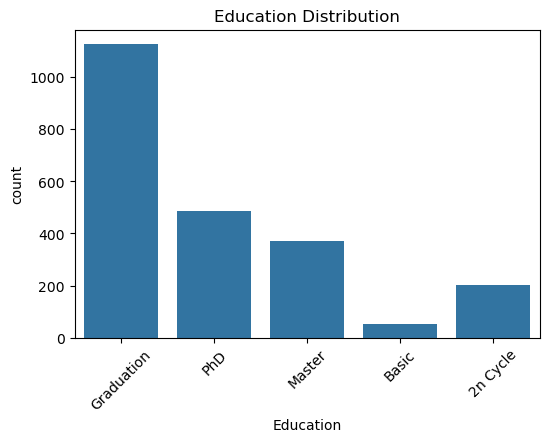

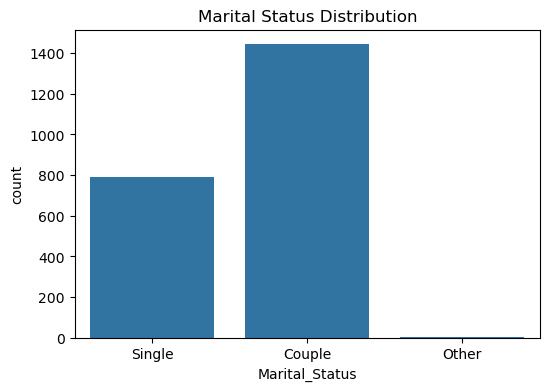

In [12]:
# Categorical features 
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Education')
plt.xticks(rotation=45)
plt.title('Education Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Marital_Status')
plt.title('Marital Status Distribution')
plt.show()

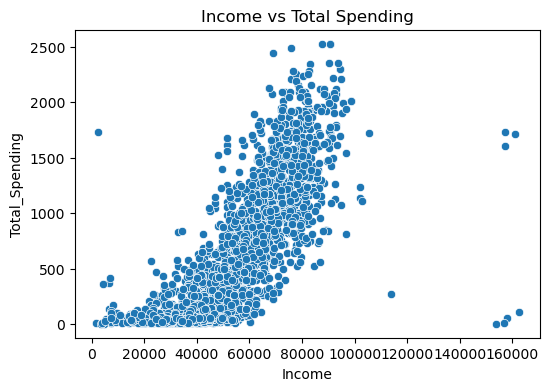

In [13]:
# Bivariate Relationships
# Income vs spending
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Income', y='Total_Spending')
plt.title('Income vs Total Spending')
plt.show()

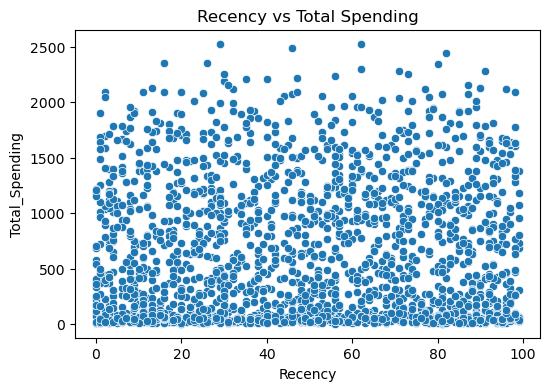

In [14]:
# Recency vs spending 
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Recency', y='Total_Spending')
plt.title('Recency vs Total Spending')
plt.show()

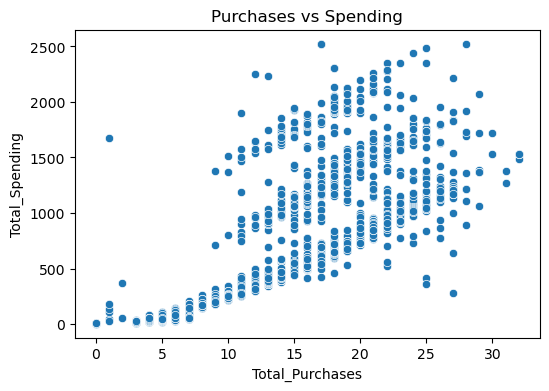

In [23]:
# Purchases vs spending 
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Total_Purchases', y='Total_Spending')
plt.title('Purchases vs Spending')
plt.show()

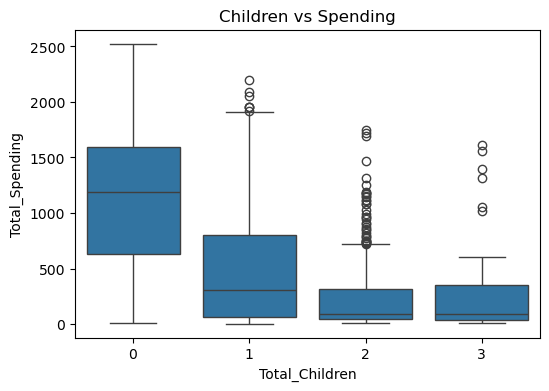

In [16]:
# children vs spending 
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Total_Children', y='Total_Spending')
plt.title('Children vs Spending')
plt.show()

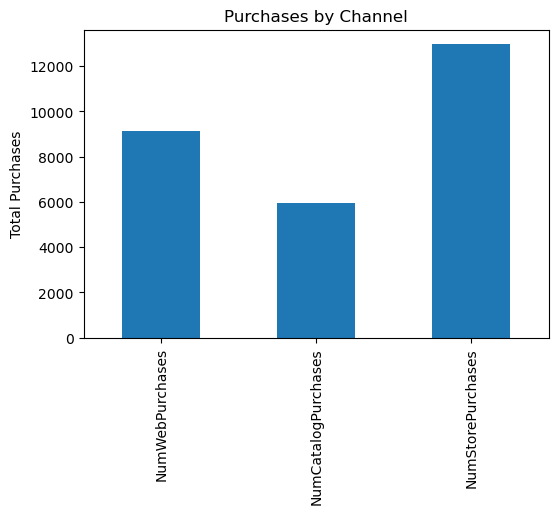

In [17]:
# Channel behavior
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

df[channel_cols].sum().plot(kind='bar', figsize=(6,4))
plt.title('Purchases by Channel')
plt.ylabel('Total Purchases')
plt.show()

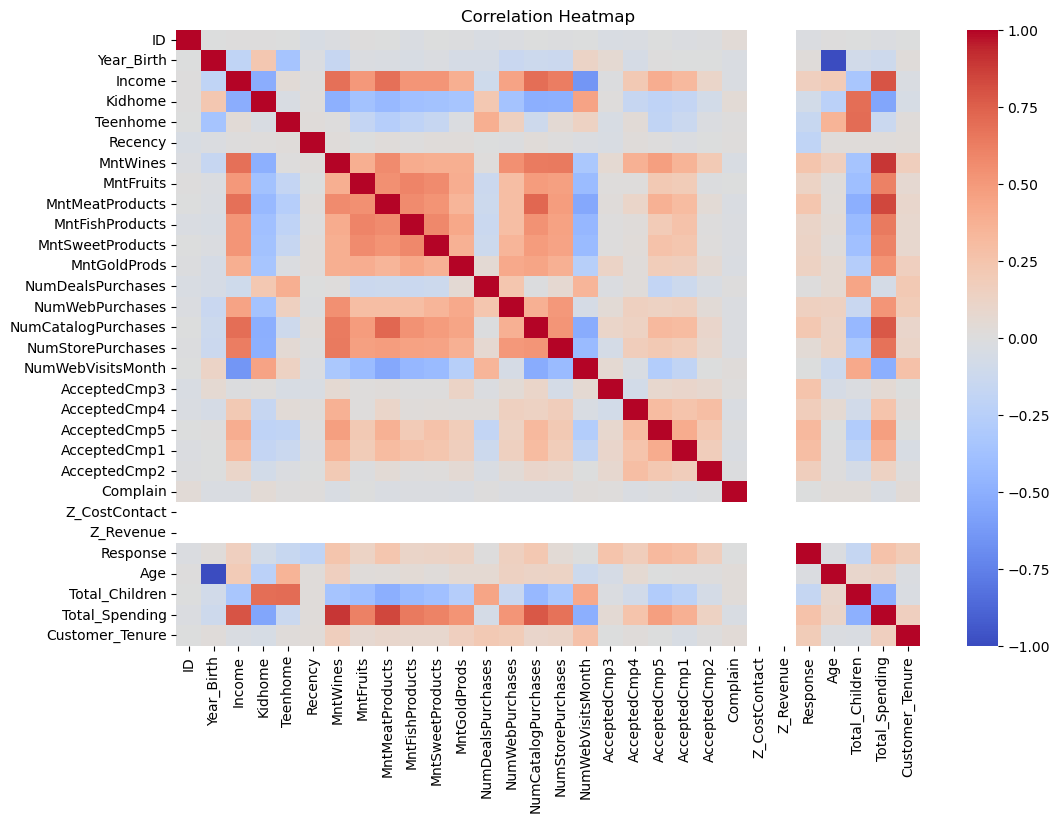

In [18]:
# Correlation Analysis 
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

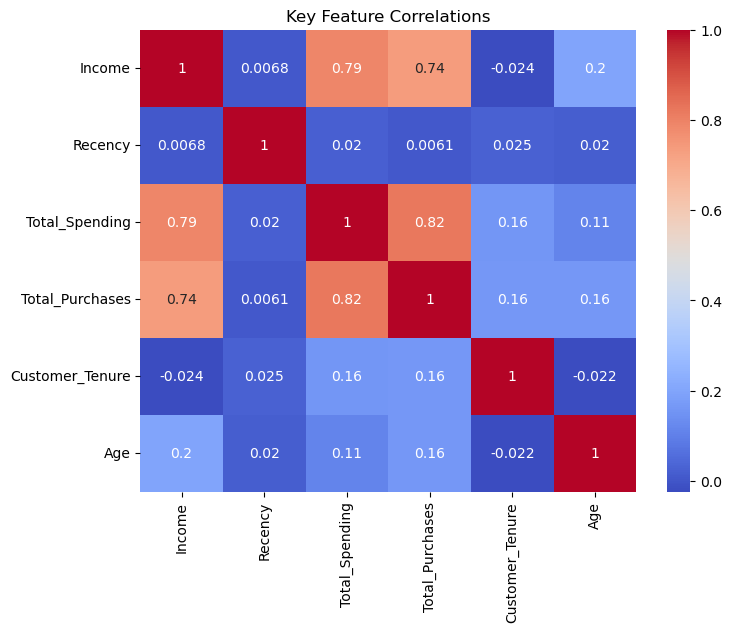

In [24]:
# Focused correlation 
important_cols = [
    'Income', 'Recency', 'Total_Spending',
    'Total_Purchases', 'Customer_Tenure', 'Age'
]

plt.figure(figsize=(8,6))
sns.heatmap(df[important_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Key Feature Correlations')
plt.show()